In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("smartcart_customers.csv")

In [4]:
df.shape

(2240, 22)

In [5]:
df.head()
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## Handle missing values

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [14]:
# Age.
df["Age"] = 2026 - df["Year_Birth"]

In [16]:
# Customer Joining Date.
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
ref_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days

In [17]:
# Total Spending.
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [19]:
# Total Children.
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [26]:
# Education
df["Education"].value_counts()

# UnderGraduate -> 2n cycle + basic
# Graduate -> graduation
# PostGraduate -> phd + master

df["Education"] = df["Education"].replace({
    "Graduation":"Graduate", 
    "PhD":"PostGraduate", "Master":"PostGraduate", 
    "2n Cycle":"UnderGraduate", "Basic":"UnderGraduate"
})

In [30]:
# Marital Status
df["Marital_Status"].value_counts()

df["Living_with"] = df["Marital_Status"].replace({
    "Married":"Partner", "Together":"Partner", 
    "Single":"Alone", "Divorced":"Alone", "Widow":"Alone", "Absurd":"Alone", "YOLO":"Alone"
})

In [32]:
df.head()
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Columns

In [37]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [41]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

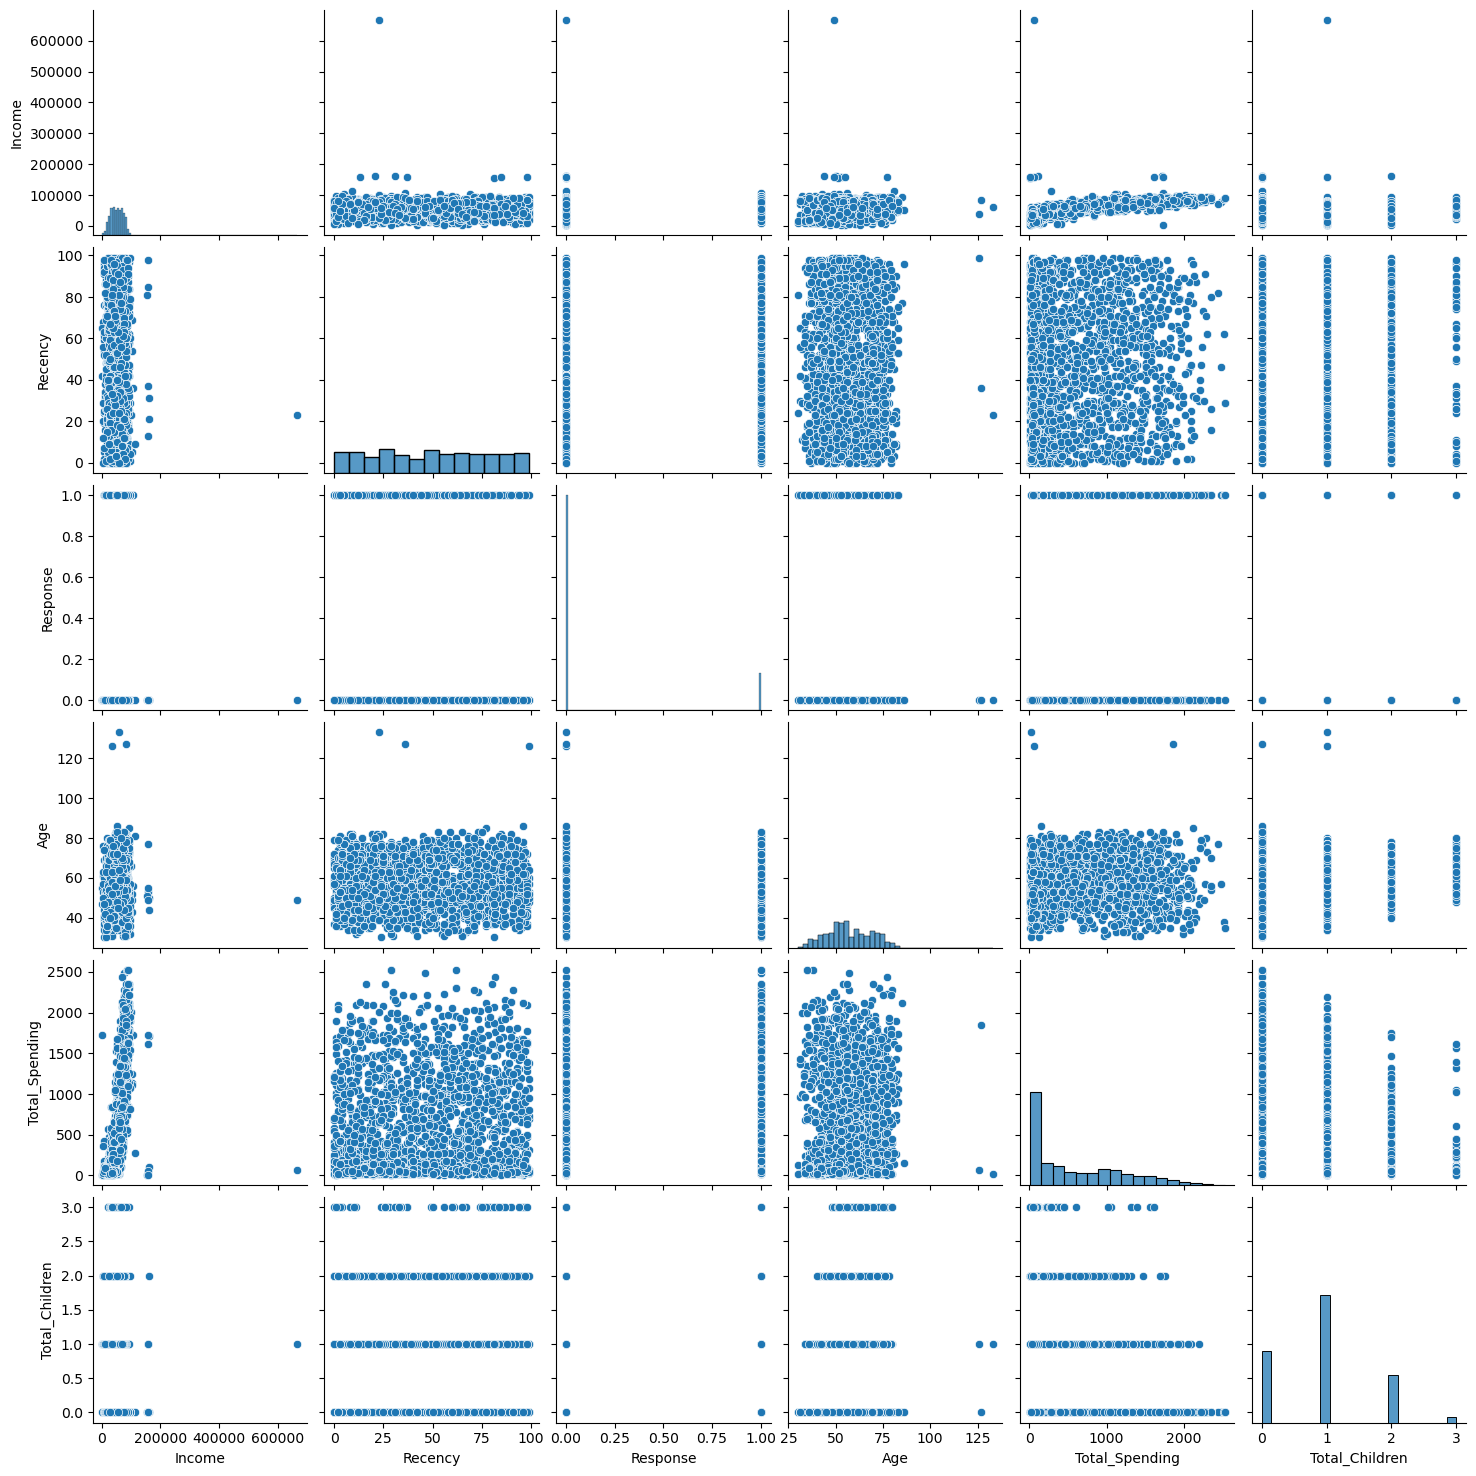

In [43]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Relative plots of some features -> pair plots
sns.pairplot(df_cleaned[cols])

In [44]:
# Remove outliers
print(f"Data with outliers : {len(df_cleaned)}")

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print(f"Data with outliers : {len(df_cleaned)}")

Data with outliers : 2240
Data with outliers : 2236


# Heatmaps

In [45]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

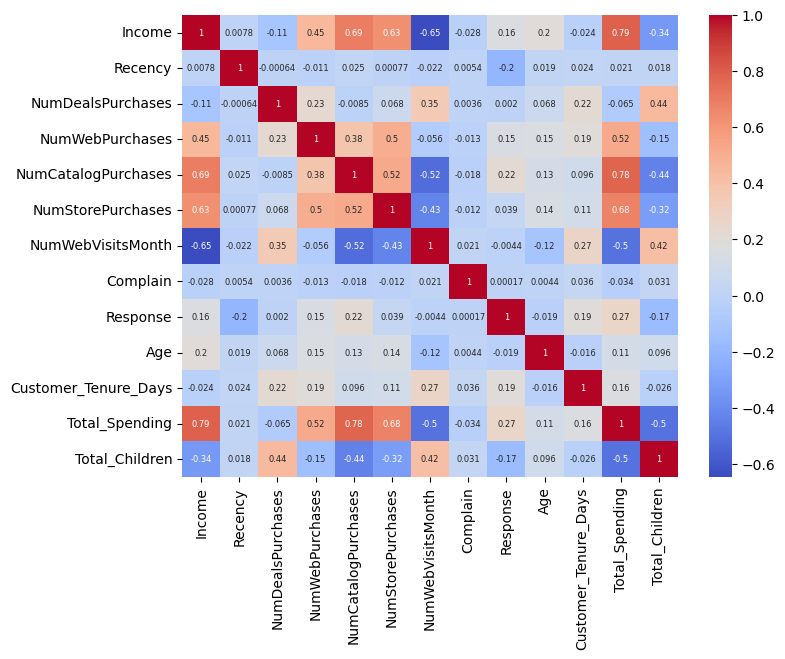

In [47]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr, 
    annot=True,
    annot_kws={"size" : 6},
    cmap="coolwarm"
)

# Encoding

In [48]:
from sklearn.preprocessing import OneHotEncoder

In [49]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [50]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [51]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [53]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [55]:
df_encoded.shape

(2236, 18)

# Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
X = df_encoded

In [58]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [60]:
X_scaled.shape

(2236, 18)

## 2D - Visualization

In [61]:
from sklearn.decomposition import PCA

In [62]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

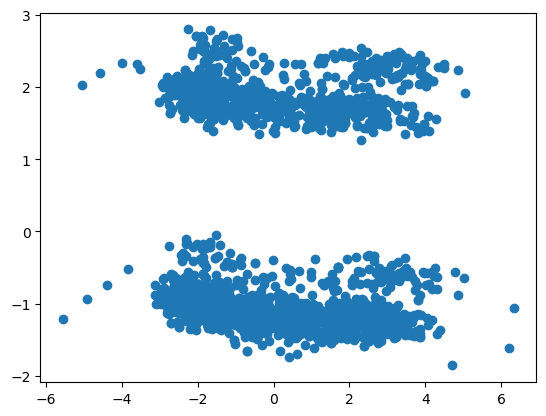

In [63]:
# Plot
plt.scatter(x=X_pca[:, 0], y=X_pca[:, 1])

In [65]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

## 3D - Visualization

In [66]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [67]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

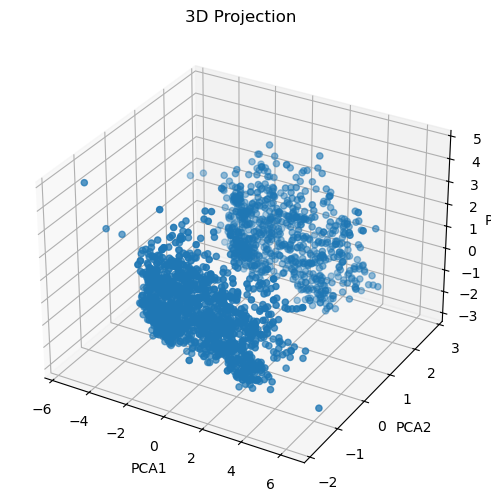

In [68]:
# Plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

# Analysing k-value

## Elbow Method

In [71]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [74]:
wcss = []

for k in range (1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [75]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [77]:
print(f"Best value of k using elbow method is : {optimal_k}.")

Best value of k using elbow method is : 4.


Text(0, 0.5, 'WCSS')

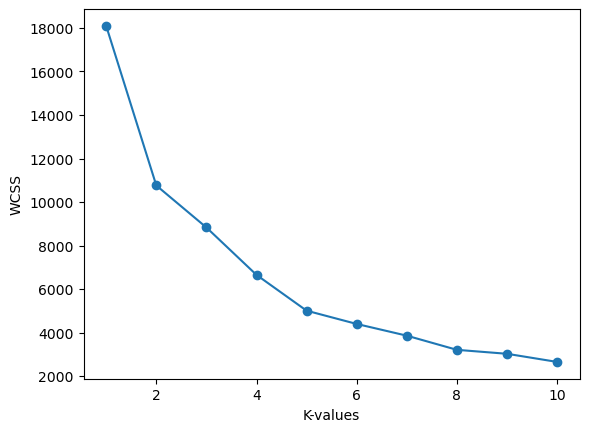

In [81]:
# Plot 
plt.plot(range(1, 11), wcss, marker = "o")
plt.xlabel("K-values")
plt.ylabel("WCSS")

## Silhouette Score

In [82]:
from sklearn.metrics import silhouette_score

Text(0, 0.5, 'Silhouette Score')

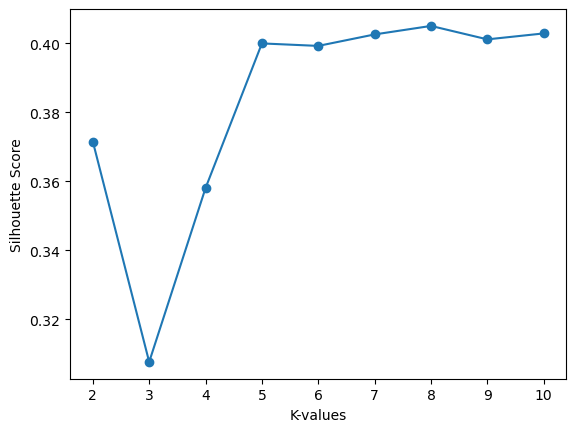

In [83]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot
plt.plot(range(2, 11), scores, marker = "o")
plt.xlabel("K-values")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'Silhouette Scores')

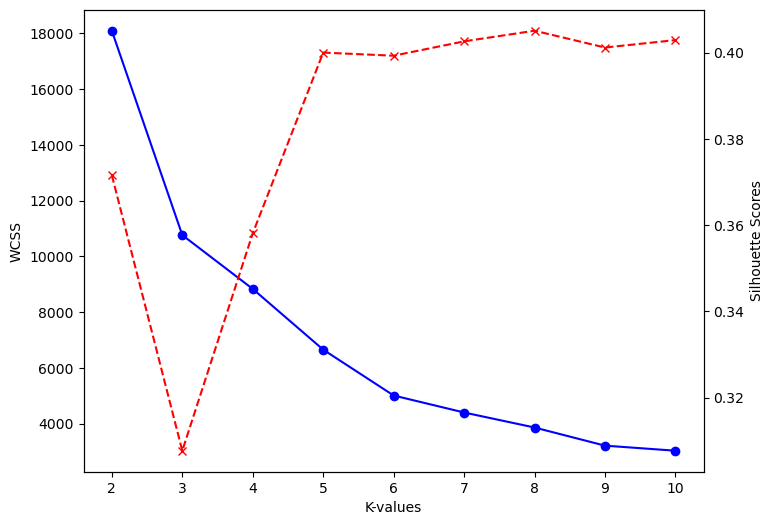

In [88]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize = (8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker = "o", color= "blue")
ax1.set_xlabel("K-values")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker = "x", color = "red", linestyle = "--")
ax2.set_ylabel("Silhouette Scores")

# Clustering

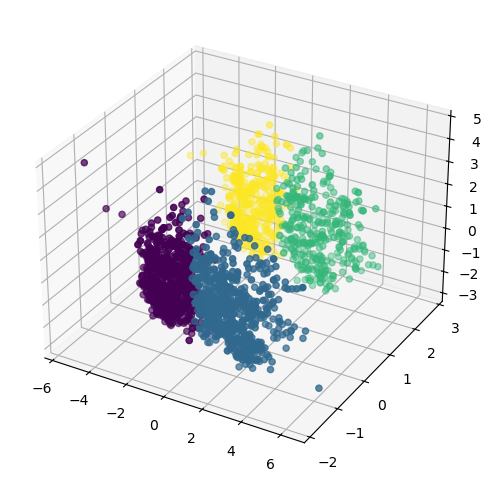

In [89]:
# K-means
k_means = KMeans(n_clusters=4)
labels_kmeans = k_means.fit_predict(X_pca)

# Visualise
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels_kmeans)

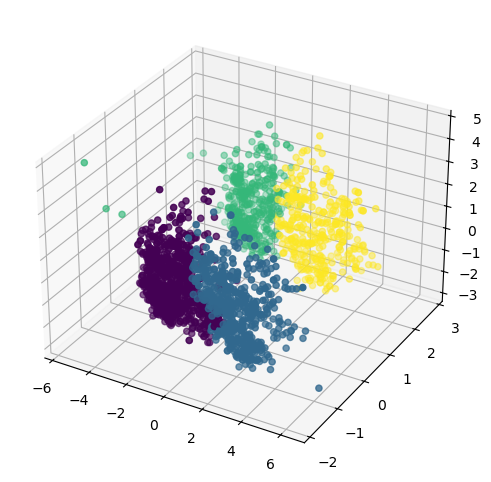

In [90]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg.fit_predict(X_pca)

# Visualise
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels_agg)

# Characterization of Clusters

In [92]:
X["Clusters"] = labels_agg

In [93]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Clusters', ylabel='count'>

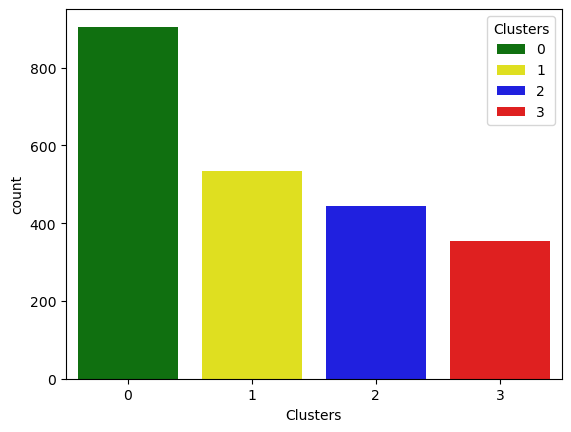

In [94]:
pal = ["green", "yellow", "blue", "red"]

sns.countplot(x=X["Clusters"], palette=pal, hue=X["Clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

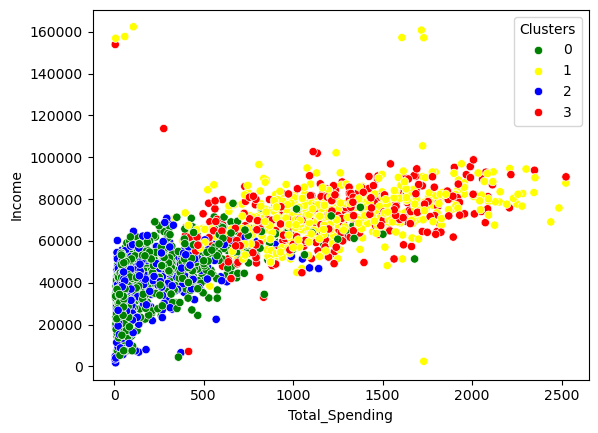

In [100]:
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["Clusters"], palette = pal)

In [103]:
# Cluster Summary
cluster_summary = X.groupby("Clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
Clu